In [1]:
import os
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, ToolMessage

load_dotenv()
if os.getenv("GROQ_API_KEY"):
    print("API Key Loaded")

API Key Loaded


In [2]:
llm = ChatGroq(model = "openai/gpt-oss-120b")

### **Pydantic LLM Schema**

In [3]:
from pydantic import BaseModel, Field
from typing import List, TypedDict

class llm_schema(BaseModel):
    tasks:List[str] = Field(...,description = "A List Of Tasks To Be Performed By The Worker")
    
llm_with_schema = llm.with_structured_output(llm_schema)

### **Graph Schema**

In [4]:
class graph_schema(TypedDict):
    tasks:List[str]
    query:str
    result:List[str]
    summary:str

### **Creating Orchestrator Node**

In [5]:
def orchestrator_node(state:graph_schema) -> graph_schema:
    user_query = state['query']
    
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system","you are a orchestrator that breaks down a user query into tasks for the worker."),
            ("user",f"User Query: {user_query}. Please generate one prompt for the worker to complete.")
        ]
    )
    
    chain = prompt | llm_with_schema
    
    response = chain.invoke({"query":user_query})
    
    state['tasks'] = response.tasks
    
    return state

### **Worker Node**

In [6]:
def execute(query:str) :
    
    response = llm.invoke(f"Please Execute This task {query} ")
    
    return response.content

In [7]:
from concurrent.futures import ThreadPoolExecutor

def worker_node(state:graph_schema) -> graph_schema:
    
    tasks = state['tasks']
    results = []
    
    with ThreadPoolExecutor(max_workers= len(tasks)) as executer:
        results_futures = executer.map(execute, tasks)
        for result in results_futures:
                   results.append(result)
    
    state['result'] = results
    
    return state

### **Collector Node**

In [8]:
def collector_node(state:graph_schema):
    results = state['result']
    
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system","You Are A Collector That Summarizes The Results From The Worker"),
            ("user","Here are the results from the worker: {results}. Please summarize these results")
        ]
    )
    
    chain = prompt | llm
    
    summary = chain.invoke({"results":results})
    
    state['summary'] = summary
    
    return state

### **Creating Graph And Executing**

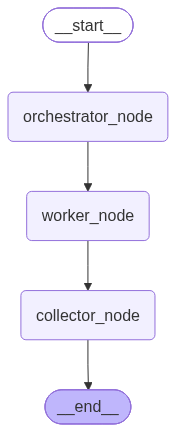

In [9]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("orchestrator_node",orchestrator_node)
graph.add_node("worker_node",worker_node)
graph.add_node("collector_node",collector_node)

graph.add_edge(START, "orchestrator_node")
graph.add_edge("orchestrator_node", "worker_node")
graph.add_edge("worker_node", "collector_node")
graph.add_edge("collector_node", END)

complex_graph = graph.compile()
complex_graph

In [10]:
complex_graph.invoke({
    "query":"Who Is Elon Musk & His Child Names",
    "tasks":[],
    "result":[],
    "summary":""
    })

{'tasks': ['Provide a concise biography of Elon Musk, covering his background, major achievements, and current roles.',
  "List the names of all of Elon Musk's children, including any publicly known details."],
 'query': 'Who Is Elon Musk & His Child Names',
 'result': ['**Elon Musk – Concise Biography**\n\n**Background**  \n- **Full Name:** Elon Reeve Musk  \n- **Born:** June\u202f28\u202f1971, Pretoria, South Africa  \n- **Education:** Attended Pretoria Boys High School; briefly studied at the University of Pretoria before moving to Canada. Earned a B.Sc. in Physics and a B.A. in Economics from the University of Pennsylvania (Wharton School). Began a Ph.D. in Applied Physics at Stanford University but left after two days to pursue entrepreneurial ventures.  \n\n**Major Achievements**  \n\n| Year | Venture / Milestone | Significance |\n|------|---------------------|--------------|\n| **1995** | Co‑founded Zip2 (online city guide) | Sold to Compaq for $307\u202fM (1999). |\n| **1999** 